# 05 Práctica de laboratorio: Clasificación supervisada con k-NN y evaluación de modelos

**Aprendizaje Computacional I**

**Nombre y apellidos:** Miguel Adrian Gheorghe

# Introducción

En esta práctica trabajaremos con un problema real de clasificación supervisada utilizando el algoritmo de los **k-vecinos más próximos (k-NN)**.

El objetivo será construir un sistema capaz de clasificar tumores de mama como **malignos** o **benignos** utilizando medidas obtenidas a partir de imágenes digitalizadas de biopsias.

Además de entrenar modelos k-NN, estudiaremos la influencia de la distancia utilizada, el efecto del escalado de variables, la elección adecuada del parámetro $k$ y distintas métricas de evaluación.

La práctica también servirá para comprender algunos problemas importantes del aprendizaje automático: sobreajuste, validación, clases desbalanceadas y selección de hiperparámetros.

CUANDO aparezca una PREGUNTA teórica o de interpretación, RESPONDE en la celda Markdown situada justo debajo, sustituyendo el texto entre corchetes.

# Objetivos

Al finalizar esta práctica deberías ser capaz de:

- cargar y analizar un dataset real,
- dividir datos en entrenamiento y prueba,
- aplicar escalado de variables,
- entrenar clasificadores k-NN,
- comparar distintas métricas de distancia,
- seleccionar el valor adecuado de $k$,
- construir matrices de confusión,
- calcular accuracy, precision, recall y F1-score,
- interpretar curvas ROC y AUC,
- comparar modelos utilizando validación.

# Dataset: Breast Cancer Wisconsin

Usaremos el dataset **Breast Cancer Wisconsin Diagnostic Dataset**, incluido en `scikit-learn`.

Este dataset contiene medidas extraídas de imágenes de células obtenidas mediante biopsias de mama. Cada ejemplo corresponde a un tumor.

La variable objetivo tiene dos posibles valores:

- 0 → maligno
- 1 → benigno

El dataset contiene 30 variables numéricas.

# Preparación del entorno

## Ejercicio 1

Importa las librerías necesarias. Necesitarás al menos `numpy`, `pandas`, `matplotlib`, `seaborn` y módulos de `sklearn`. Introduce tu código de estudiante donde pone CODIGO_ESTUDIANTE. 

In [94]:
# COMPLETAR CODIGO_ESTUDIANTE
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Función que carga el dataset
from sklearn.datasets import load_breast_cancer

# División, validación y preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelo
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (7, 5)

CODIGO_ESTUDIANTE = 40 # sustituye por tu código de estudiante
np.random.seed(CODIGO_ESTUDIANTE)

# Carga del dataset

## Ejercicio 2

Carga el dataset Breast Cancer Wisconsin usando `sklearn.datasets`. ¿Cuántas variables predictores, objetivo y clases hay en este dataset?

In [95]:
# COMPLETAR
cancer = load_breast_cancer()

print(f"Número de muestras: {len(cancer.data)}")
print(f"Número de variables predictoras: {len(cancer.feature_names)}")
print(f"Hay {cancer.target_names.size} objetivos: {cancer.target_names}")

Número de muestras: 569
Número de variables predictoras: 30
Hay 2 objetivos: ['malignant' 'benign']


## Ejercicio 3

Crea un `DataFrame` llamado `datos` con las variables predictoras y una columna adicional llamada `target`.

Muestra las primeras filas, el número de ejemplos y el número de variables.

In [96]:
# COMPLETAR
datos = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
datos["target"] = cancer.target

print(f"Primeras filas:\n{datos.head()}")
print(f"Número de muestras: {datos.shape[0]}")
print(f"Número de variables predictoras (excluyendo target): {datos.shape[1] - 1}")

Primeras filas:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  radius error  texture error  perimeter error  \
0

## Ejercicio 4

Estudia la distribución de clases (muestra una tabla y una figura).

Preguntas:

1. ¿Hay el mismo número de tumores benignos y malignos?
2. ¿Crees que esto puede afectar a algunas métricas?

Distribución de clases:


target
0    212
1    357
Name: count, dtype: int64

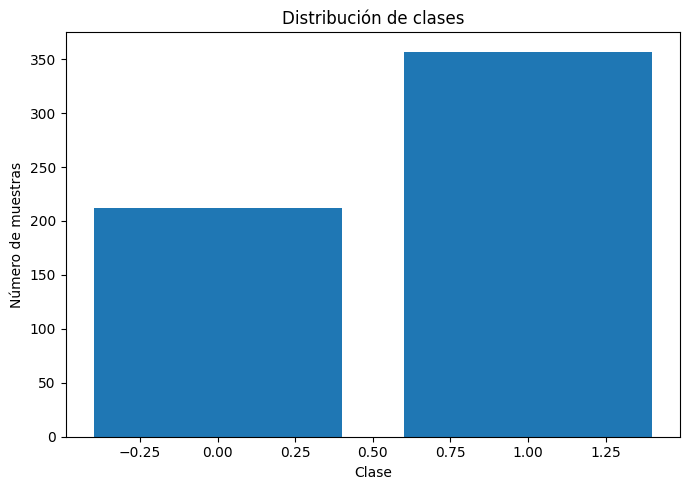

In [97]:
# COMPLETAR
print(f"Distribución de clases:")
display(datos.target.value_counts().sort_index())

plt.figure(figsize=(7, 5))
plt.bar(sorted(datos.target.unique()), datos.target.value_counts().sort_index())
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.tight_layout()
plt.show()

**Respuesta.**

No, el número no es igual; las clases están desbalanceadas, ya que hay más casos benignos que malignos. Este desequilibrio afecta a métricas como el accuracy, que puede ser engañoso al no reflejar fallos en la clase minoritaria. Por ello, resulta útil emplear el F1-score para equilibrar la precisión y el recall, priorizando minimizar errores críticos como los falsos negativos en salud.

# Exploración inicial de los datos

## Ejercicio 5

Calcula media, desviación típica, mínimo y máximo para todas las variables (muéstralos en forma de tabla).

In [98]:
# COMPLETAR
metricas = pd.DataFrame()
metricas["media"] = datos.mean()
metricas["desviacion tipica"] = datos.std()
metricas["minimo"] = datos.min()
metricas["maximo"] = datos.max()

display(metricas)

,media,desviacion tipica,minimo,maximo
mean radius,14.127292,3.524049,6.981000,28.11000
mean texture,19.289649,4.301036,9.710000,39.28000
mean perimeter,91.969033,24.298981,43.790000,188.50000
mean area,654.889104,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.014064,0.052630,0.16340
mean compactness,0.104341,0.052813,0.019380,0.34540
mean concavity,0.088799,0.079720,0.000000,0.42680
mean concave points,0.048919,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.007060,0.049960,0.09744


## Ejercicio 6

Representa un mapa de correlaciones entre variables.

Pregunta:

- ¿Observas variables muy correlacionadas?

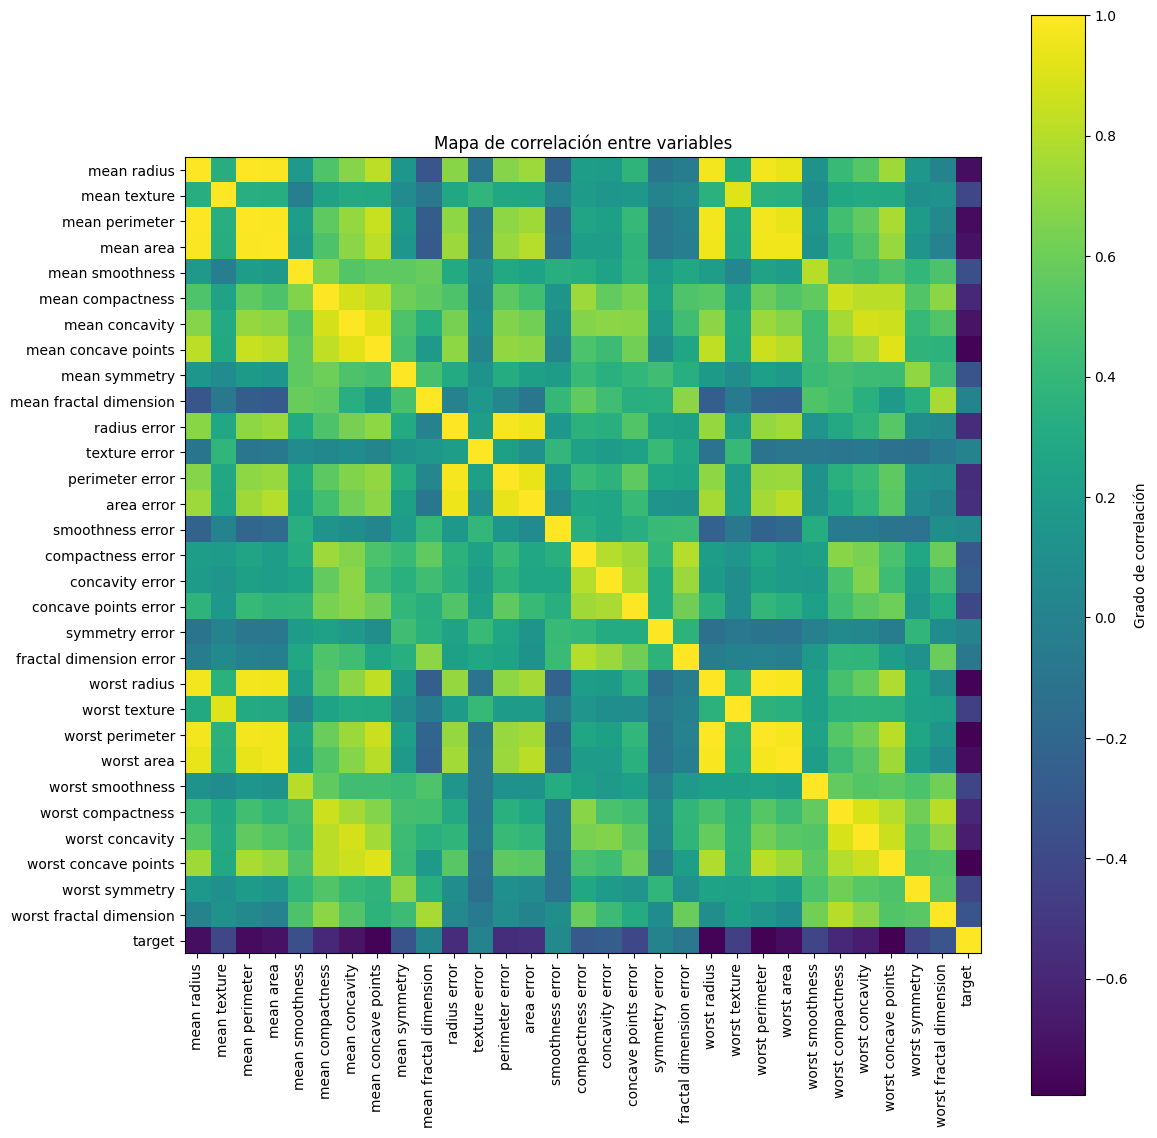

In [99]:
# COMPLETAR
correlacion = datos.corr()

plt.figure(figsize=(12, 12))
plt.imshow(correlacion)
plt.colorbar(label="Grado de correlación")
plt.xticks(range(len(datos.columns)), datos.columns, rotation=90)
plt.yticks(range(len(datos.columns)), datos.columns)
plt.title("Mapa de correlación entre variables")
plt.tight_layout()
plt.show()

**Respuesta.**

Sí, se observan correlaciones extremas ($\rho > 0.9$) entre variables como el radio, el perímetro y el área, ya que dependen matemáticamente entre sí. También existe una redundancia significativa entre las medidas de "mean", "worst" y "error" para esas mismas variables. Identificar estas relaciones es un paso clave para detectar problemas y localizar patrones que ayuden a mejorar el modelo.

# División entrenamiento/prueba

## Ejercicio 7

Divide los datos en entrenamiento (80%) y prueba (20%) utilizando:

- `random_state = CODIGO_ESTUDIANTE`
- estratificación respecto a la clase.

La opción `stratify=y` conserva aproximadamente la proporción de clases en entrenamiento y prueba.

Pregunta: ¿Cuál es la distribución de las clases en entrenamiento y en prueba? 

Distribución de clases en el conjunto de entrenamiento:


target
0    170
1    285
Name: count, dtype: int64

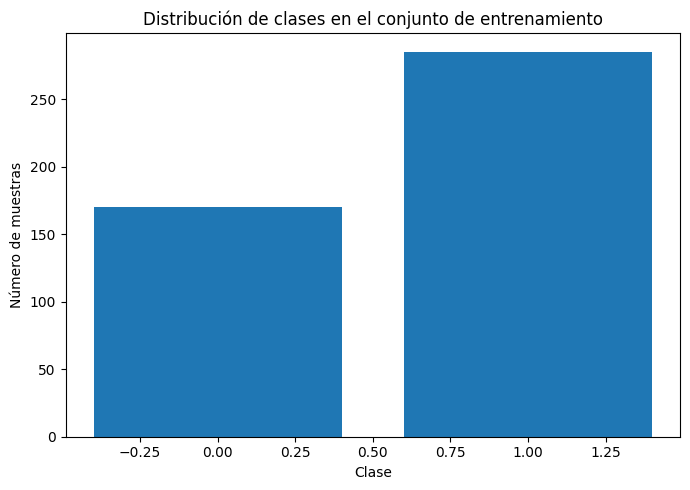

Distribución de clases en el conjunto de test:


target
0    42
1    72
Name: count, dtype: int64

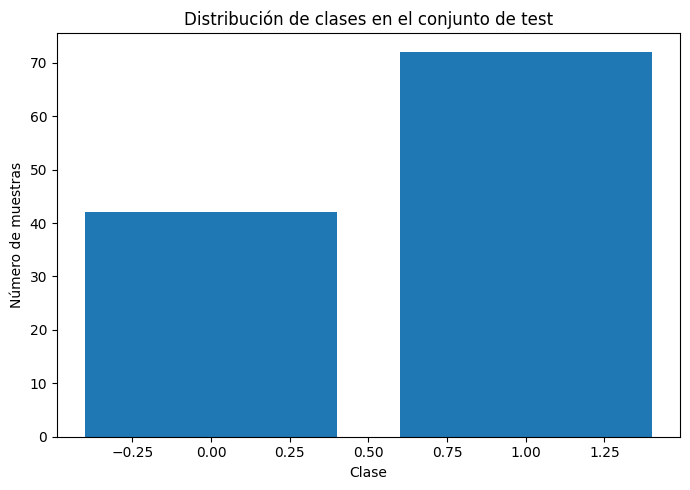

In [100]:
# COMPLETAR
X_train, X_test, y_train, y_test = train_test_split(
    datos.drop("target", axis=1), 
    datos["target"],
    train_size=0.8, 
    test_size=0.2, 
    random_state=CODIGO_ESTUDIANTE, 
    stratify=datos["target"]
)

print(f"Distribución de clases en el conjunto de entrenamiento:")
display(y_train.value_counts().sort_index())

plt.figure(figsize=(7, 5))
plt.bar(sorted(y_train.unique()), y_train.value_counts().sort_index())
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.tight_layout()
plt.show()

print(f"Distribución de clases en el conjunto de test:")
display(y_test.value_counts().sort_index())

plt.figure(figsize=(7, 5))
plt.bar(sorted(y_test.unique()), y_test.value_counts().sort_index())
plt.title("Distribución de clases en el conjunto de test")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.tight_layout()
plt.show()

**Respuesta.**

Al usar el parámetro stratify, la proporción de cada clase (malignos y benignos) es idéntica tanto en el conjunto de entrenamiento como en el de test, replicando la distribución del dataset original. El volumen se divide en un 80% para que el modelo aprenda y un 20% para medir su rendimiento final. Este equilibrio asegura que ambos grupos sean representativos.

# Primer modelo k-NN

## Ejercicio 8

Entrena un clasificador k-NN usando $k=3$ y distancia euclídea, sin escalado. 

Ayuda: Usa la función `KNeighborsClassifier()`.

In [101]:
# COMPLETAR
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

## Ejercicio 9

Calcula accuracy, precision, recall y F1-score.

Ayuda: toma la clase **maligna** como clase positiva para calcular precision, recall y F1.

In [102]:
# COMPLETAR
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

Accuracy: 0.9386
Precision: 0.9268
Recall: 0.9048
F1-score: 0.9157


## Ejercicio 10

Construye la matriz de confusión.

Preguntas:

1. ¿Qué tipo de error sería más grave en este problema?
2. ¿Falsos positivos o falsos negativos?
3. ¿Qué métrica te parece más importante?

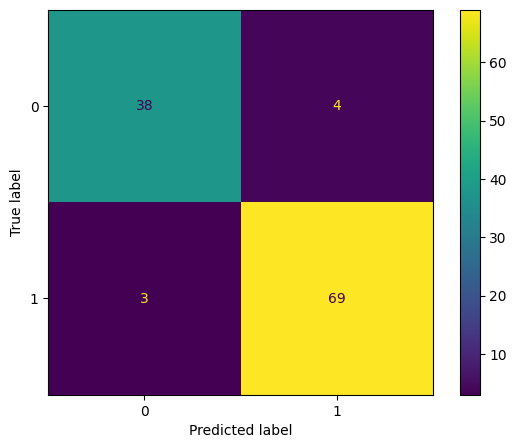

In [103]:
# COMPLETAR
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()
plt.show()

**Respuesta.**

El error más grave es el falso negativo, ya que implica no diagnosticar un tumor maligno y dejar al paciente sin tratamiento. Por ello, la métrica más importante es el recall, que cuantifica qué proporción de los positivos reales se detectan bien. Maximizar esta métrica es la prioridad en salud.

# Influencia del escalado

## Ejercicio 11

Entrena de nuevo el modelo anterior **sin escalar** las variables.

Después:

1. Escala las variables usando `StandardScaler()`.
2. Entrena el mismo modelo.
3. Compara los resultados.

Pregunta:

- ¿Por qué k-NN suele requerir escalado?

In [105]:
# COMPLETAR
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn_scaled.fit(X_train_scaled, y_train)
y_pred_scaled = knn_scaled.predict(X_test_scaled)

accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled, pos_label=0)
recall_scaled = recall_score(y_test, y_pred_scaled, pos_label=0)
f1_scaled = f1_score(y_test, y_pred_scaled, pos_label=0)

print(f"Accuracy: {accuracy_scaled:.4f}")
print(f"Precision: {precision_scaled:.4f}")
print(f"Recall: {recall_scaled:.4f}")
print(f"F1-score: {f1_scaled:.4f}")

Accuracy: 0.9825
Precision: 1.0000
Recall: 0.9524
F1-score: 0.9756


**Respuesta.**

k-NN requiere escalado porque basa su clasificación en la proximidad entre puntos del dataset. Sin este proceso, las variables con rangos numéricos más amplios dominarían el cálculo de distancias, lo que impediría una correcta generalización y estabilidad en el rendimiento del modelo. Al normalizar, todas las características influyen equitativamente, mejorando drásticamente el equilibrio entre precisión y recall reflejado en un mayor F1-score.

# Influencia del número de vecinos

## Ejercicio 12

Estudia el rendimiento del clasificador para distintos valores de $k$.

Usa al menos:

$$
k \in \{1,3,5,7,9,11,15,21\}
$$

Obtén una tabla con los resultados. Representa gráficamente accuracy frente a $k$.

,k,Accuracy,Precision,Recall,F1-score
0,1,0.964912,0.952381,0.952381,0.952381
1,3,0.982456,1.000000,0.952381,0.975610
2,5,0.991228,1.000000,0.976190,0.987952
3,7,0.991228,1.000000,0.976190,0.987952
4,9,0.991228,1.000000,0.976190,0.987952
5,11,0.991228,1.000000,0.976190,0.987952
6,15,0.991228,1.000000,0.976190,0.987952
7,21,0.982456,1.000000,0.952381,0.975610


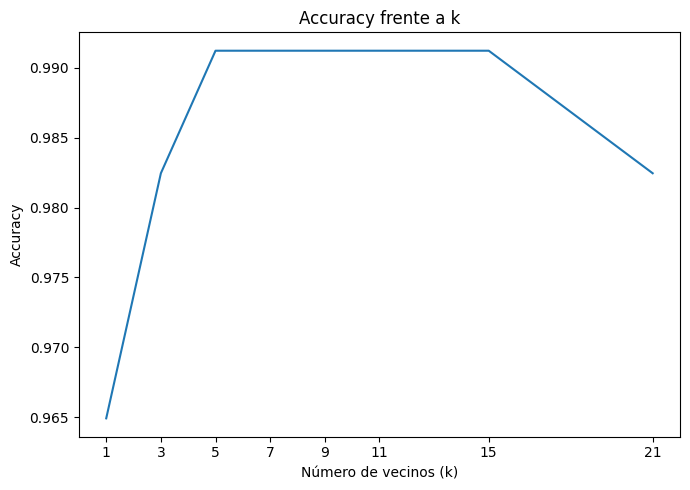

In [109]:
# COMPLETAR
ks = [1, 3, 5, 7, 9, 11, 15, 21]
resultados = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    resultados.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=0),
        "Recall": recall_score(y_test, y_pred, pos_label=0),
        "F1-score": f1_score(y_test, y_pred, pos_label=0)
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

plt.figure(figsize=(7, 5))
plt.plot(df_resultados["k"], df_resultados["Accuracy"])
plt.title("Accuracy frente a k")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(ks)
plt.tight_layout()
plt.show()

## Ejercicio 13

Pregunta:

1. ¿Qué ocurre para valores muy pequeños de $k$?
2. ¿Y para valores muy grandes?
3. ¿Dónde parece producirse sobreajuste?

Escribe una breve explicación.

**Respuesta.**

Para valores muy pequeños como k=1, el modelo se vuelve excesivamente complejo y memoriza detalles irrelevantes o ruido de los datos, lo que provoca overfitting. En cambio, valores muy grandes simplifican demasiado la frontera de decisión, pudiendo causar underfitting al no captar patrones importantes. El sobreajuste es evidente en k=1, mientras que valores intermedios logran una mejor generalización y estabilidad en las predicciones.

# Comparación de métricas de distancia

## Ejercicio 14

Compara distancia euclídea y distancia Manhattan. Usa el mismo valor de $k$.

In [111]:
# COMPLETAR
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric="manhattan")
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)

accuracy_mahattan = accuracy_score(y_test, y_pred_manhattan)
precision_mahattan = precision_score(y_test, y_pred_manhattan, pos_label=0)
recall_mahattan = recall_score(y_test, y_pred_manhattan, pos_label=0)
f1_mahattan = f1_score(y_test, y_pred_manhattan, pos_label=0)

print(f"Accuracy: {accuracy_mahattan:.4f}")
print(f"Precision: {precision_mahattan:.4f}")
print(f"Recall: {recall_mahattan:.4f}")
print(f"F1-score: {f1_mahattan:.4f}")

Accuracy: 0.9912
Precision: 0.9767
Recall: 1.0000
F1-score: 0.9882


## Ejercicio 15

Pregunta:

- ¿Qué métrica funciona mejor en este dataset?
- ¿Las diferencias son grandes o pequeñas?

**Respuesta.**

La métrica de Manhattan funciona mejor en este escenario al alcanzar un Recall de 1, garantizando que no se escape ningún tumor maligno (cero falsos negativos), prioridad absoluta en salud. Aunque las diferencias en Accuracy y F1-score son pequeñas, son estadísticamente relevantes para elegir la configuración con mejor rendimiento global. Manhattan ofrece un equilibrio superior entre aciertos y errores, superando a la Euclídea en casi todos los frentes para este dataset específico.

# Validación cruzada

## Ejercicio 16

Utiliza validación cruzada `cross_val_score()` para seleccionar el mejor valor de $k$.

Usa validación cruzada de 5 particiones.

Obtén una tabla con el resultado. Representa en un gráfico accuracy media y desviación típica.

<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_12793/403035438.py:22: SyntaxWarning: invalid escape sequence '\p'
  label='Exactitud Media $\pm$ $\sigma$'


,k,Mean Accuracy,Std Accuracy
0,1,0.940659,0.026556
1,3,0.949451,0.022628
2,5,0.960440,0.017855
3,7,0.958242,0.027274
4,9,0.947253,0.025441
5,11,0.951648,0.021534
6,15,0.947253,0.022413
7,21,0.945055,0.018388


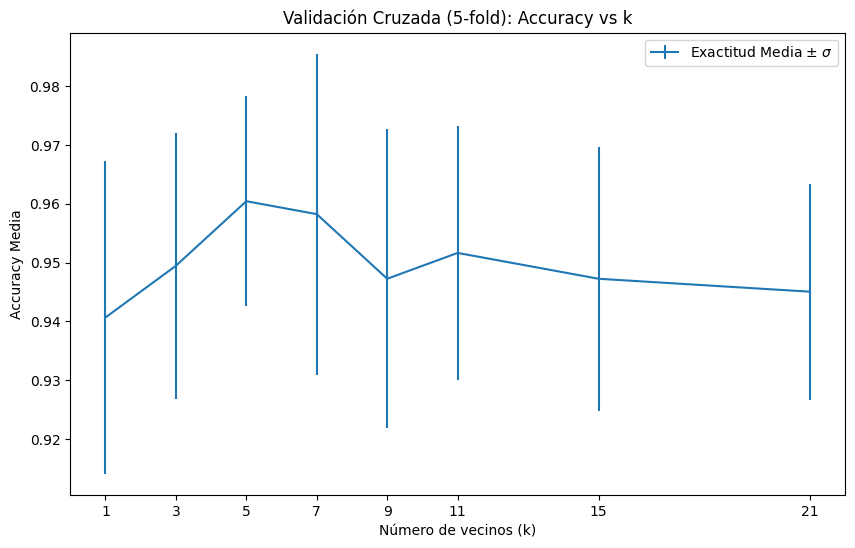

In [117]:
# COMPLETAR
resultados = []

for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")

    resultados.append({
        "k": k, 
        "Mean Accuracy": scores.mean(), 
        "Std Accuracy": scores.std()
    })

df_cv = pd.DataFrame(resultados)
display(df_cv)

plt.figure(figsize=(10, 6))
plt.errorbar(
    df_cv["k"], 
    df_cv["Mean Accuracy"], 
    yerr=df_cv["Std Accuracy"],
    label='Exactitud Media $\pm$ $\sigma$'
)

plt.title("Validación Cruzada (5-fold): Accuracy vs k")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy Media")
plt.xticks(ks)
plt.legend()
plt.show()

## Ejercicio 17

Pregunta:

- ¿Por qué la validación cruzada suele ser más fiable que usar una sola partición entrenamiento/prueba?

**Respuesta.**

La validación cruzada es más fiable porque evalúa el modelo en múltiples particiones distintas, evitando que los resultados dependan del azar de una única división. Al promediar los aciertos en varios folds, se obtiene una estimación mucho más robusta y realista de la capacidad de generalización del modelo. Además, permite cuantificar la estabilidad del rendimiento mediante la desviación típica, algo imposible con una partición única.

# Curva ROC y AUC

## Ejercicio 18

Calcula la curva ROC `roc_curve()` y el AUC `roc_auc_score()`. Representa gráficamente la curva ROC.

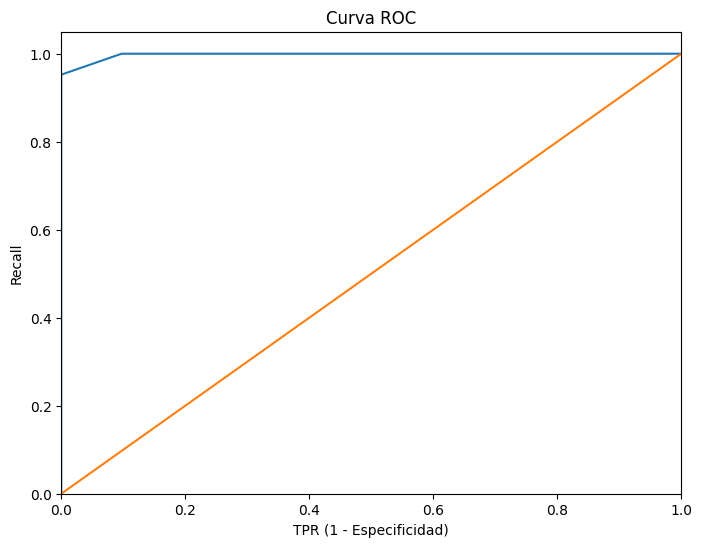

Área bajo la curva (AUC): 0.9977


In [125]:
# COMPLETAR
y_probs = knn_scaled.predict_proba(X_test_scaled)[:, 0]
fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=0)
auc = roc_auc_score(y_test == 0, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], label='Azar (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("TPR (1 - Especificidad)")
plt.ylabel("Recall")
plt.title("Curva ROC")
plt.show()

print(f"Área bajo la curva (AUC): {auc:.4f}")

## Ejercicio 19

Pregunta:

1. ¿Qué significa el área bajo la curva ROC?
2. ¿Qué valor tendría un clasificador aleatorio?
3. ¿Qué valor tendría un clasificador perfecto?

**Respuesta.**

El AUC cuantifica la capacidad global del modelo para separar las clases, indicando la probabilidad de que un positivo real sea puntuado por encima de un negativo. Un clasificador aleatorio obtiene un valor de 0.5, mientras que uno ideal o perfecto alcanza el 1.0.

# Comparación final de modelos

## Ejercicio 20

Construye una tabla resumen comparando varios modelos k-NN.

La tabla debe incluir:

- valor de $k$,
- distancia,
- accuracy,
- precision,
- recall,
- F1,
- AUC.

In [126]:
# COMPLETAR
configuraciones = [
    {"k": 1, "dist": "euclidean"},
    {"k": 3, "dist": "euclidean"},
    {"k": 3, "dist": "manhattan"},
    {"k": 9, "dist": "euclidean"},
    {"k": 9, "dist": "manhattan"}
]

resumen = []

for config in configuraciones:
    knn = KNeighborsClassifier(n_neighbors=config["k"], metric=config["dist"])
    knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    y_probs = knn.predict_proba(X_test_scaled)[:, 0]
    
    resumen.append({
        "k": config["k"],
        "Distancia": config["dist"],
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, pos_label=0),
        "Recall": recall_score(y_test, y_pred, pos_label=0),
        "F1-score": f1_score(y_test, y_pred, pos_label=0),
        "AUC": roc_auc_score(y_test == 0, y_probs)
    })

df_comparativo = pd.DataFrame(resumen)
display(df_comparativo)

,k,Distancia,Accuracy,Precision,Recall,F1-score,AUC
0,1,euclidean,0.964912,0.952381,0.952381,0.952381,0.962302
1,3,euclidean,0.982456,1.000000,0.952381,0.975610,0.997685
2,3,manhattan,0.991228,0.976744,1.000000,0.988235,0.999504
3,9,euclidean,0.991228,1.000000,0.976190,0.987952,0.999504
4,9,manhattan,0.982456,0.976190,0.976190,0.976190,0.999173


# Ejercicio final de reflexión

Responde brevemente a las siguientes preguntas.

1. ¿Por qué k-NN se considera un método basado en instancias?
2. ¿Por qué el escalado es importante?
3. ¿Qué ventajas tiene k-NN?
4. ¿Qué inconvenientes tiene?
5. ¿Qué métrica utilizarías si el objetivo fuera minimizar falsos negativos?
6. ¿Qué diferencias existen entre accuracy y F1-score?
7. ¿Por qué ROC/AUC puede ser útil cuando las clases están desbalanceadas?

**Respuesta (responde a cada pregunta con 1. respuesta; 2. respuesta; etc.).**

1. Se denomina así porque no construye un modelo matemático previo ni aprende una función global; simplemente memoriza los datos de entrenamiento. Para clasificar una nueva muestra, consulta directamente estas "instancias" guardadas en memoria para encontrar las más parecidas, por lo que también se conoce como lazy learning.
2. Al basarse en distancias, variables con rangos numéricos grandes dominarían injustamente el cálculo sobre variables con rangos pequeños. El escalado asegura que todas las características tengan el mismo peso y contribuyan equitativamente a la decisión final.
3. Es sencillo e intuitivo, no requiere una fase de entrenamiento costosa y es muy flexible para adaptarse a fronteras de decisión complejas. No asume ninguna distribución específica de los datos, siendo ideal para problemas donde no conocemos la estructura de la información.
4. Es muy costoso computacionalmente durante la fase de prueba, ya que debe calcular la distancia contra todos los puntos cada vez que hace una predicción. Además, consume mucha memoria al guardar todo el dataset y es muy sensible a la presencia de variables irrelevantes o ruido en los datos.
5. El Recall. En problemas médicos, esta métrica es vital porque mide qué proporción de positivos reales (malignos) estamos detectando correctamente. Maximizar el recall garantiza que no dejemos a pacientes enfermos sin diagnóstico, aunque eso suponga aumentar ligeramente los falsos positivos.
6. La Accuracy mide los aciertos globales pero puede ser engañosa si las clases están desbalanceadas (podría dar un 90% de aciertos simplemente prediciendo siempre la clase mayoritaria). El F1-score es la media armónica entre precisión y recall; solo es alto si ambos son buenos, lo que lo convierte en una medida mucho más honesta y equilibrada.
7. Porque el AUC mide la capacidad del modelo para separar las clases independientemente del umbral de decisión elegido. A diferencia de la exactitud, el AUC nos indica si el modelo es capaz de puntuar sistemáticamente a un positivo por encima de un negativo, lo que permite evaluar el poder de discriminación real incluso si una clase es mucho más rara que la otra.

# Entrega

La entrega debe incluir:

- el notebook completado,
- todas las gráficas,
- respuestas razonadas,
- interpretación de resultados.

No basta con ejecutar código: las respuestas deben explicar qué significan los resultados obtenidos.

# Comentario sobre el código de estudiante

En esta práctica todos los estudiantes trabajarán con el mismo dataset completo, pero utilizarán distintos valores de `random_state` derivados de su código de estudiante.

Esto hace que:

- las particiones entrenamiento/prueba cambien ligeramente,
- los resultados numéricos no sean exactamente iguales,
- pero todos trabajen sobre el mismo problema y puedan compararse resultados.

Esta estrategia suele ser más recomendable que dar subconjuntos distintos del dataset, porque:

- evita que algunos estudiantes reciban subconjuntos demasiado fáciles o difíciles,
- facilita la corrección,
- permite discutir resultados comunes en clase,
- y mantiene cierta personalización.